In [1]:
from PA_OmniNet.testing_model import LightningModel
from PA_OmniNet.helper_functions import *
import matplotlib.pyplot as plt
from PA_OmniNet.unet1 import UNet
from PA_OmniNet.testing_functions import *
from torchmetrics.image import StructuralSimilarityIndexMeasure
ssim = StructuralSimilarityIndexMeasure()

In [2]:
mice = ['../Datasets/optoacousticsparse/mice_sparse16_recon_256.mat', '../Datasets/optoacousticsparse/mice_sparse32_recon_256.mat', '../Datasets/optoacousticsparse/mice_sparse128_recon_256.mat']
v_phantom = ['../Datasets/optoacousticsparse/v_phantom_sparse16_recon_256.mat', '../Datasets/optoacousticsparse/v_phantom_sparse32_recon_256.mat', '../Datasets/optoacousticsparse/v_phantom_full_recon_256.mat']
phantom = ['../Datasets/optoacousticsparse/phantom_sparse16_recon_256.mat', '../Datasets/optoacousticsparse/phantom_sparse32_recon_256.mat', '../Datasets/optoacousticsparse/phantom_full_recon_256.mat']


In [3]:
Unet_mouse16_path = 'final_model_weight/Mice/best_model_mouse16_2.pth'
Unet_mouse16 = UNet()
Unet_mouse16.load_state_dict(torch.load(Unet_mouse16_path, map_location=torch.device('cpu')))
Unet_mouse16.eval()  

Unet_mouse32_path = 'final_model_weight/Mice/best_model_mouse32.pth'
Unet_mouse32 = UNet()
Unet_mouse32.load_state_dict(torch.load(Unet_mouse32_path, map_location=torch.device('cpu')))
Unet_mouse32.eval()   

Unet_phantom16_path = 'final_model_weight/Mice/best_model_phantom16.pth'
Unet_phantom16 = UNet()
Unet_phantom16.load_state_dict(torch.load(Unet_phantom16_path, map_location=torch.device('cpu')))
Unet_phantom16.eval()  

Unet_phantom32_path = 'final_model_weight/Mice/best_model_phantom32.pth'
Unet_phantom32 = UNet()
Unet_phantom32.load_state_dict(torch.load(Unet_phantom32_path, map_location=torch.device('cpu')))
Unet_phantom32.eval()  

Unet_vphantom16_path = 'final_model_weight/Mice/best_model_vphantom16_split.pth'
Unet_vphantom16 = UNet()
Unet_vphantom16.load_state_dict(torch.load(Unet_vphantom16_path, map_location=torch.device('cpu')))
Unet_vphantom16.eval()  

Unet_vphantom32_path = 'final_model_weight/Mice/best_model_vphantom32_split.pth'
Unet_vphantom32 = UNet()
Unet_vphantom32.load_state_dict(torch.load(Unet_vphantom32_path, map_location=torch.device('cpu')))
Unet_vphantom32.eval()  

UnetSWFDSemi = 'final_model_weight/Unet/best_model_Semi.pth'
Unet_Semi_model = UNet()
Unet_Semi_model.load_state_dict(torch.load(UnetSWFDSemi, map_location=torch.device('cpu')))
Unet_Semi_model.eval()  
print('Loaded')

C:\Users\olivi\AppData\Local\Temp\ipykernel_313376\1465240836.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Unet_mouse16.load_state_dict(torch.load(Unet_mouse16_path, 

Loaded


C:\Users\olivi\AppData\Local\Temp\ipykernel_313376\1465240836.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  Unet_vphantom32.load_state_dict(torch.load(Unet_vphantom32

In [4]:
def preprocess_mat_mouse(image, size=(256, 256)):
    image = (image - image.min()) / (image.max() - image.min())
    # image = cv2.resize(image, size, interpolation=cv2.INTER_LINEAR)
    # image = np.stack([image] * 3, axis=-1)
    image = torch.tensor(image)
    image = image.unsqueeze(0)
    # image = image.permute(0, 3, 1, 2).float()
    return image

def preprocess_batch_mouse(images, size=(256, 256)):
    processed_images = []
    for image in images:
        processed_image = preprocess_mat_mouse(image, size)
        processed_images.append(processed_image)

    return torch.cat(processed_images, dim=0)


def data_loader_formatter_mat_mouse(in_filepath, out_filepath):
    with h5py.File(in_filepath, 'r') as infile:
        first_key = list(infile.keys())[0]
        data_in = infile[first_key][()]

    with h5py.File(out_filepath, 'r') as outfile:
        first_key = list(outfile.keys())[0]
        data_out = outfile[first_key][()]

    return data_in, data_out

In [5]:
CONTEXT_SIZE = 16


X_mouse, y_mouse = data_loader_formatter_mat_mouse(mice[0], mice[2])
size_mouse = X_mouse.shape[0]
indices_mouse = np.arange(size_mouse)
train_end_mouse = int(0.7 * size_mouse)
val_end_mouse = train_end_mouse + int(0.2 * size_mouse)

train_indices_mouse = indices_mouse[:train_end_mouse]
val_indices_mouse = indices_mouse[train_end_mouse:val_end_mouse ]
test_indices_mouse = indices_mouse[val_end_mouse :]

X_train_mouse, y_train_mouse = X_mouse[train_indices_mouse], y_mouse[train_indices_mouse]
X_val_mouse, y_val_mouse = X_mouse[val_indices_mouse], y_mouse[val_indices_mouse]
X_test_mouse, y_test_mouse = X_mouse[test_indices_mouse], y_mouse[test_indices_mouse]



X_train_mouse = preprocess_batch_mouse(X_train_mouse)
y_train_mouse = preprocess_batch_mouse(y_train_mouse)

X_val_mouse = preprocess_batch_mouse(X_val_mouse)
y_val_mouse = preprocess_batch_mouse(y_val_mouse)

X_test_mouse = preprocess_batch_mouse(X_test_mouse)
y_test_mouse = preprocess_batch_mouse(y_test_mouse)

print("Train set:", X_train_mouse.shape, y_train_mouse.shape)
print("Validation set:", X_val_mouse.shape, y_val_mouse.shape)
print("Test set:", X_test_mouse.shape, y_test_mouse.shape)

Train set: torch.Size([191, 256, 256]) torch.Size([191, 256, 256])
Validation set: torch.Size([54, 256, 256]) torch.Size([54, 256, 256])
Test set: torch.Size([29, 256, 256]) torch.Size([29, 256, 256])


0.4179561806406082 7.577384962755164 0.31008872389793396


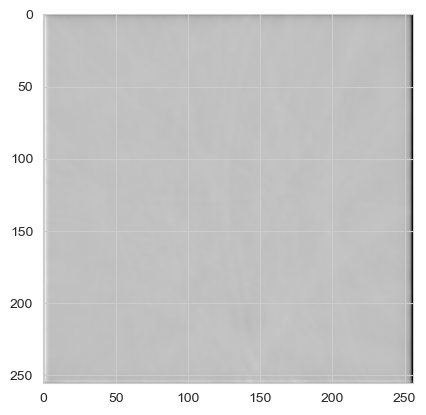

0.2570881478040418 11.798358892032079 0.3827929198741913


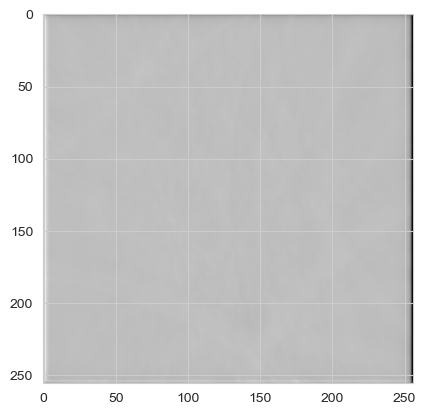

0.291103810468692 10.719042194576895 0.23719948530197144


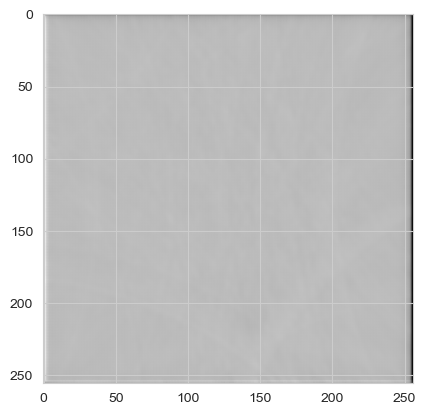

0.4220088624098497 7.493568570563709 0.2791792154312134


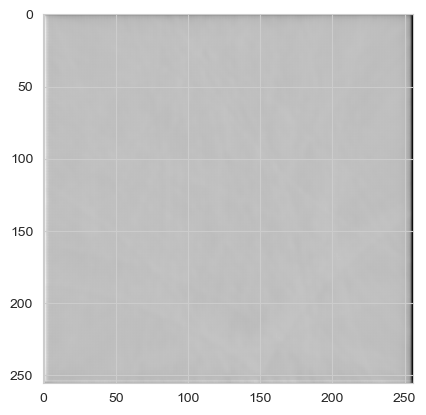

0.34246815825075266 9.307596036064657 0.40207862854003906


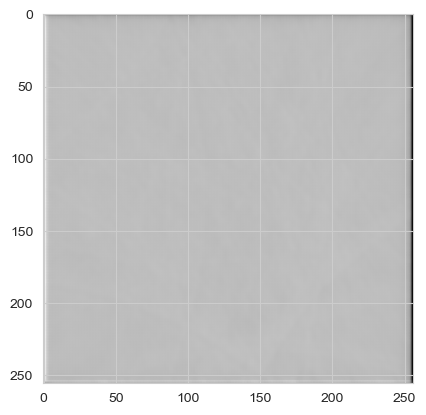

0.44078349860824734 7.115493446352464 0.3239523768424988


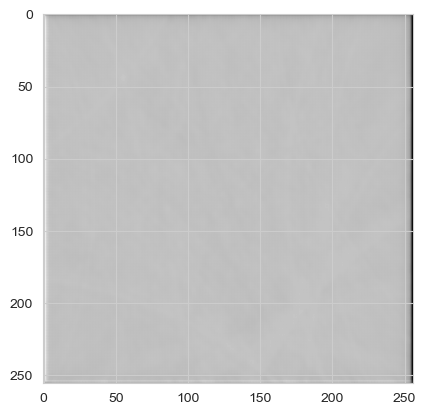

0.32433530294287344 9.780115541567373 0.3253812789916992


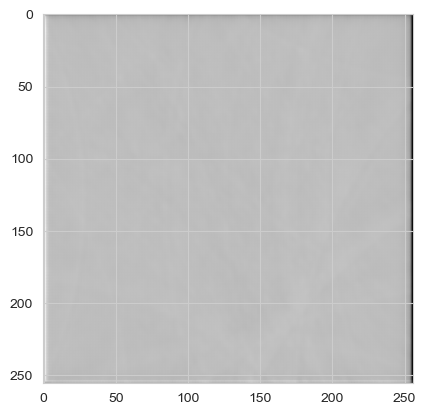

0.3717757317370195 8.594379258290697 0.2575559914112091


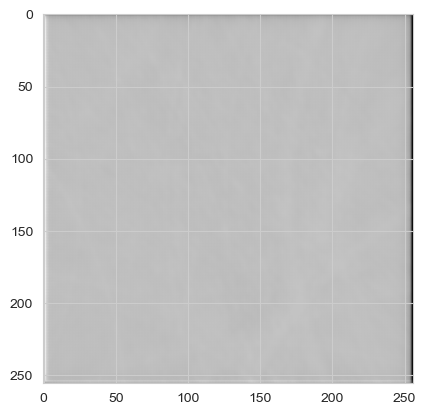

0.41863741832139467 7.563239129873343 0.291595995426178


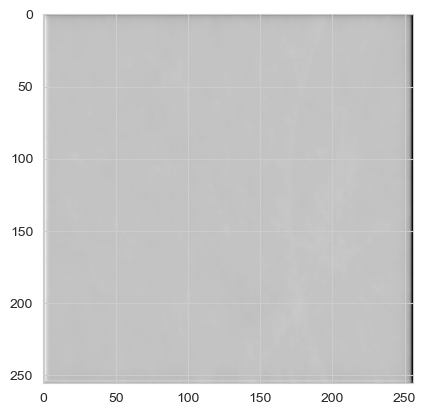

0.4896012889608383 6.203148950099471 0.2680831551551819


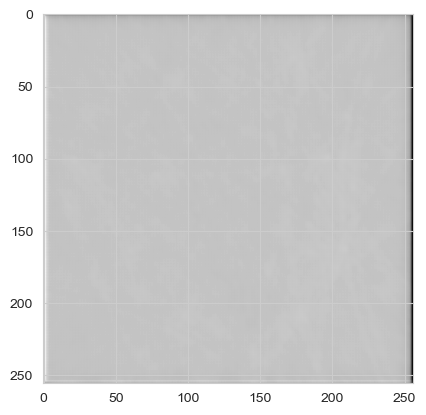

0.39940402255257396 7.971751309907788 0.3419553339481354


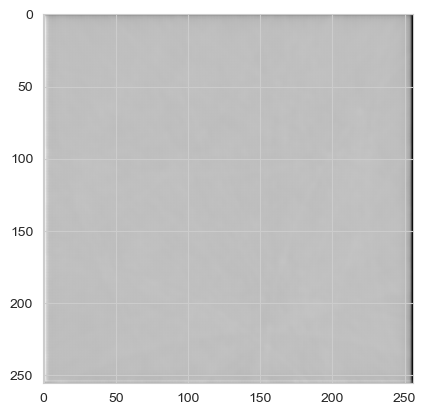

0.45027713192959146 6.930402176840797 0.27658411860466003


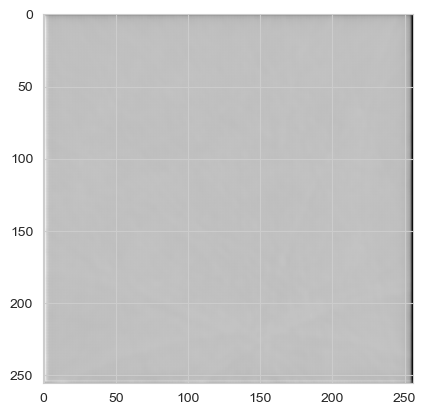

0.33857886884005867 9.406803005612655 0.33190593123435974


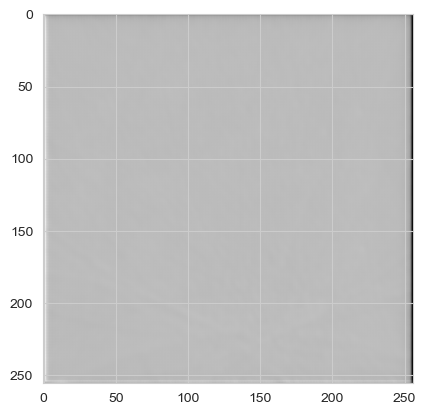

0.46127045213890144 6.720887286938365 0.308241069316864


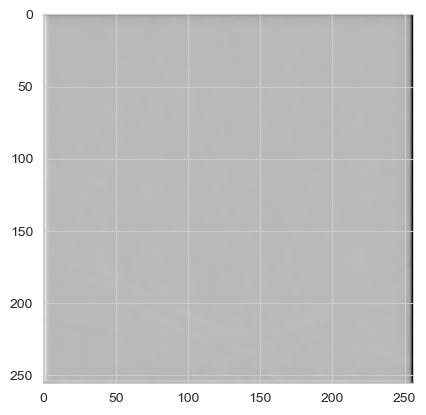

0.42534114942066936 7.42525199294063 0.2550378441810608


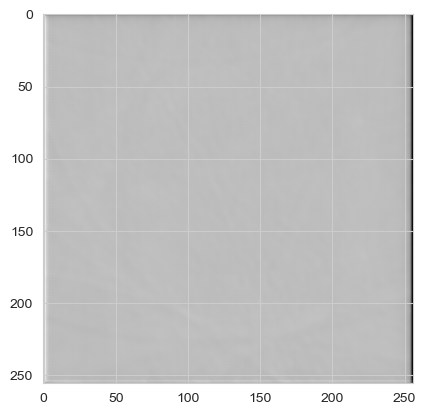

0.47630581839302255 6.442282265189173 0.22684447467327118


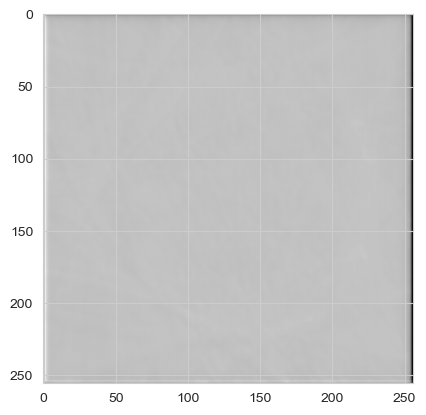

0.3325883409655525 9.561859584775851 0.36371082067489624


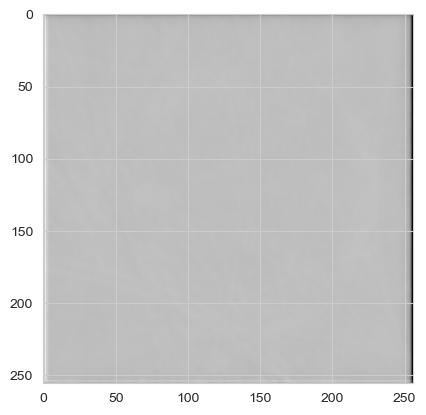

0.362673557277739 8.80968215814615 0.31682872772216797


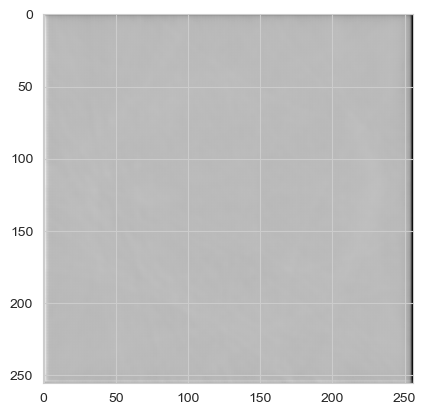

0.4254485525523226 7.423058990954088 0.20233269035816193


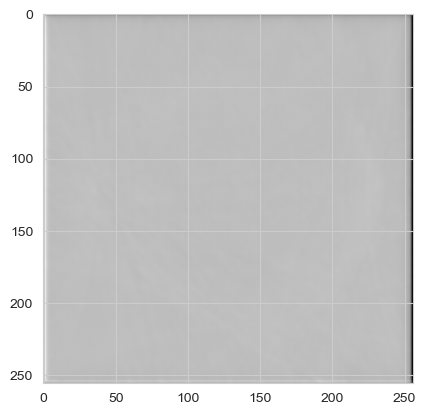

0.431417420831291 7.3020464374213 0.2228463888168335


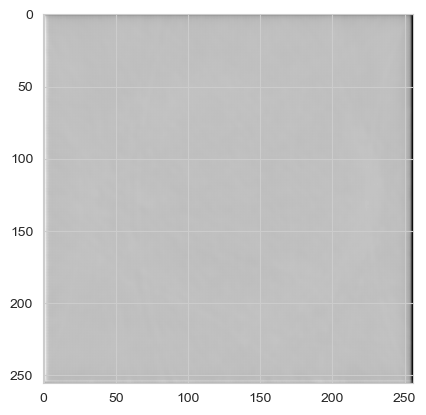

0.4134140265253252 7.6722958498104274 0.25617077946662903


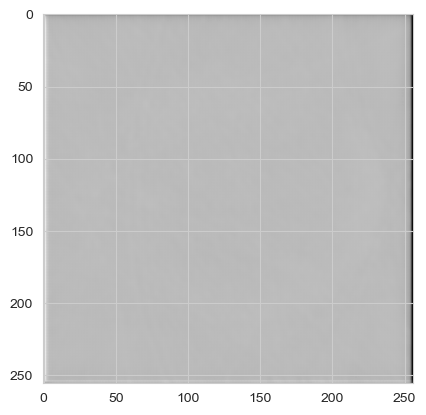

0.374313248863754 8.53529601413216 0.31425783038139343


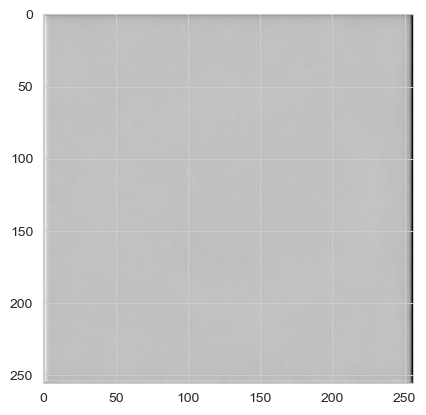

0.4642434951449834 6.665083455260933 0.27698543667793274


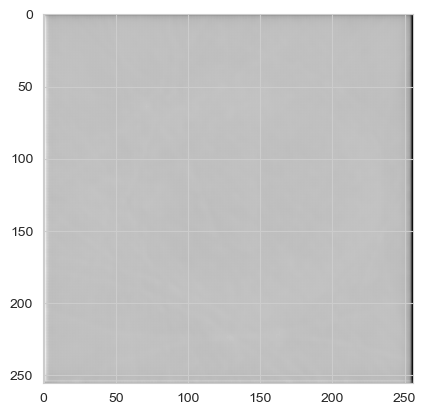

0.3508333023452458 9.097983771438523 0.3643333315849304


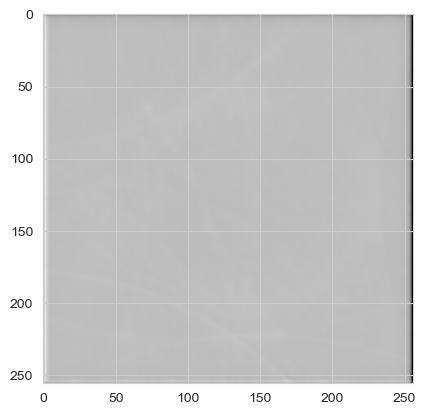

0.3564557672041005 8.95988708628565 0.3845740556716919


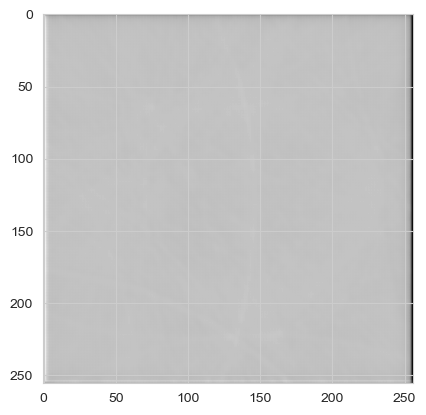

0.3734265119943878 8.555897037640815 0.30034226179122925


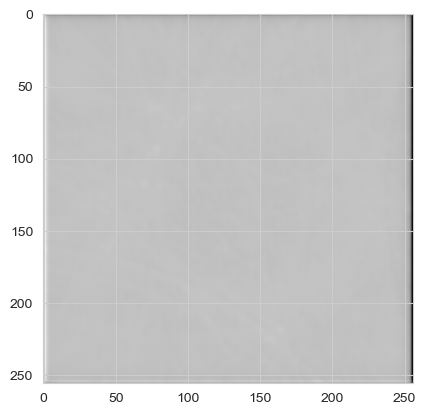

0.36662288732630705 8.715608532743097 0.3180813193321228


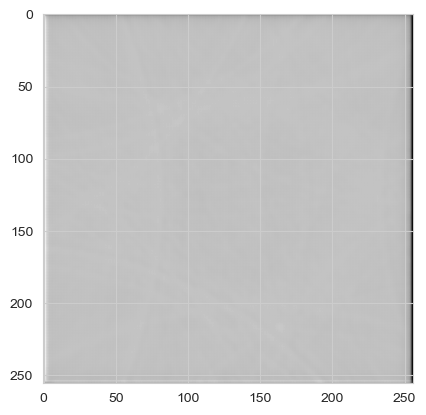

0.40920396976135454 7.761203235410252 0.26089683175086975


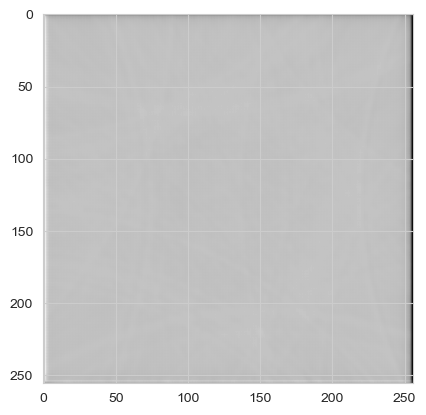

In [6]:
# csv_file_name = "Unet_mouse16_on_mouse_16.csv"  # Change the file name as needed

# with open(csv_file_name, mode="w", newline="") as file:
#     writer = csv.writer(file)
#     writer.writerow(["Index", "SSIM", "RMSE", "PSNR"])  # Write the headers
from torchmetrics.image import StructuralSimilarityIndexMeasure
ssim = StructuralSimilarityIndexMeasure(data_range=1.0)
# ssim = StructuralSimilarityIndexMeasure()
for i in range(len(X_test_mouse) - 1):
    input_mouse = X_test_mouse[i]
    
    ground_truth_mouse = y_test_mouse[i]
    # print(input.shape, ground_truth.shape)
    input_mouse = input_mouse.float() 
    input_mouse = input_mouse.unsqueeze(0)
    input_mouse = input_mouse.unsqueeze(0)
    ground_truth_mouse = ground_truth_mouse.unsqueeze(0)
    ground_truth_mouse = ground_truth_mouse.unsqueeze(0)
    output_mouse = Unet_mouse16(input_mouse)
    # print(input_mouse.shape, ground_truth_mouse.shape, output_mouse.shape)
    
    normalized_output_mouse = (output_mouse - output_mouse.min()) / (output_mouse.max() - output_mouse.min())
    normalized_input_mouse = (input_mouse - input_mouse.min()) / (input_mouse.max() - input_mouse.min())
    normalized_groundtruth_mouse = (ground_truth_mouse - ground_truth_mouse.min()) / (ground_truth_mouse.max() - ground_truth_mouse.min())
    # print(normalized_groundtruth_mouse.shape, normalized_output_mouse.shape, normalized_input_mouse.shape)
    rmse = compute_rmse(normalized_groundtruth_mouse, normalized_output_mouse)
    psnr = compute_psnr(normalized_groundtruth_mouse, normalized_output_mouse)
    ssim_value = ssim(normalized_groundtruth_mouse, normalized_output_mouse).item()
    # with open(csv_file_name, mode="a", newline="") as file:
    #     writer = csv.writer(file)
    #     writer.writerow([i, ssim_value, rmse, psnr])
    print(rmse, psnr, ssim_value)
    plt.imshow(normalized_output_mouse.squeeze(0).permute(1, 2, 0).detach().cpu().numpy(), cmap='gray')
    plt.show()